# CROCUS Network and Sensor Coverage

Start-of-session health check for the CROCUS Sage/Waggle network. Run top to
bottom to see, at a glance, which compute hosts are alive and which sensors are
reporting before you start querying data.

**Two independent views:**
1. **Node compute-host liveness** — are each node's chips (nxcore, rpi) reporting?
2. **Sensor status grid** — are the sensors themselves reporting valid data?

These answer different questions: a host can be alive while its sensors are dead.
Read the host strip first, then the sensor grid.

Links:
- Sage Data Client: https://github.com/sagecontinuum/sage-data-client
- CROCUS Instrument Cookbooks: https://crocus-urban.github.io/instrument-cookbooks/
- Sage Continuum Portal: https://portal.sagecontinuum.org/nodes/project/sage


## Google Colab setup

Run the following setup cell first when using Google Colab. It clones the
repository, installs the required packages, and makes the local helper modules
available to Python.

In a normal local Jupyter session, the cell only adds the current directory to
Python's module search path.

In [1]:
# Run this cell first when using Google Colab.

import os
import sys
from pathlib import Path

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ

if IN_COLAB:
    %cd /content

    if not Path("crocus").exists():
        !git clone -q https://github.com/gregorywanderson/crocus.git

    %cd /content/crocus
    !pip install -q -r requirements.txt

    sys.path.insert(0, "/content/crocus")
else:
    # Local use: assume the notebook is being run from the crocus repository.
    sys.path.insert(0, str(Path.cwd()))

In [2]:
# Standard library
import datetime as dt
import ssl
import importlib

# Third party
import matplotlib.pyplot as plt
import pandas as pd
import sage_data_client

# Local modules — reload so edits are picked up without restarting the kernel

import crocus_sites;   importlib.reload(crocus_sites)
import sage_utils;     importlib.reload(sage_utils)
import coverage_utils; importlib.reload(coverage_utils)

from crocus_sites import (
    ALL_SITES,
    ATMOS, BIG, CCICS, CSU, HUM, IBP, NEIU, NU, SHEDD, UIC,
)
from sage_utils import last_n_hours
from coverage_utils import (
    check_network_status, plot_network_status,
    check_node_health, plot_node_health,
    plot_node_status,
)

# Sage's data endpoint can present a certificate the default context rejects;
# disable verification for these read-only public-data queries.
ssl._create_default_https_context = ssl._create_unverified_context

# NOTE on time windows: always pass ABSOLUTE timestamps (e.g. via
# last_n_hours) to sage_data_client, never relative strings like "-2h".
# With pandas 3.x the client's relative-time parsing mis-resolves "-2h" to
# year 1, producing an HTTP 500. last_n_hours builds absolute UTC strings.


## 1. Node Compute-Host Liveness

Is each node's compute hardware reporting? Based on `sys.uptime` per host,
**role-labeled via the Sage node-manifest endpoint** — reproducing the portal's
per-node status tooltip.

One column per compute role present in the manifest:
- **nxcore** — the GPU / k3s control-plane chip.
- **rpi** — the stock Raspberry Pi.
- **rpi.lorawan** — the LoRaWAN Raspberry Pi (only on nodes that have one).
- **nxagent** — the optional second NX blade (only where present).

Each cell is colored by how recently that host last reported (portal thresholds:
green ≤3 min, orange ≤6 min, red older / never), with the age shown. Gray =
that role isn't on the node, or is marked inactive in the manifest. The role and
roster come from the manifest (per-compute `name` + `is_active`), which is the
authoritative source — no hand-maintained lorawan flag.

**Liveness only** — green means the chip is reporting, *not* that its sensors
are healthy. (NEIU is the classic case: rpi reporting, but its BME680/RG-15
dead for years — that shows in the sensor grid below, not here.)

If the manifest endpoint is unreachable, the last good roster is reused from an
in-process cache (cells flag this in the title); if nothing is cached, that node
is omitted and you can fall back to `_check_node_health_count_based`.

Checking node compute-host liveness...
  Checking ATMOS (W0A4)... done
  Checking BIG (W0A0)... done
  Checking CCICS (W08B)... done
  Checking CSU (W08E)... done
  Checking DOWN (W09D)... done
  Checking HUM (W0A1)... done
  Checking IBP (W07C)... done
  Checking NEIU (W08D)... done
  Checking NU (W099)... done
  Checking SHEDD (W09E)... done
  Checking UIC (W096)... done
  Checking VLPK (W095)... done


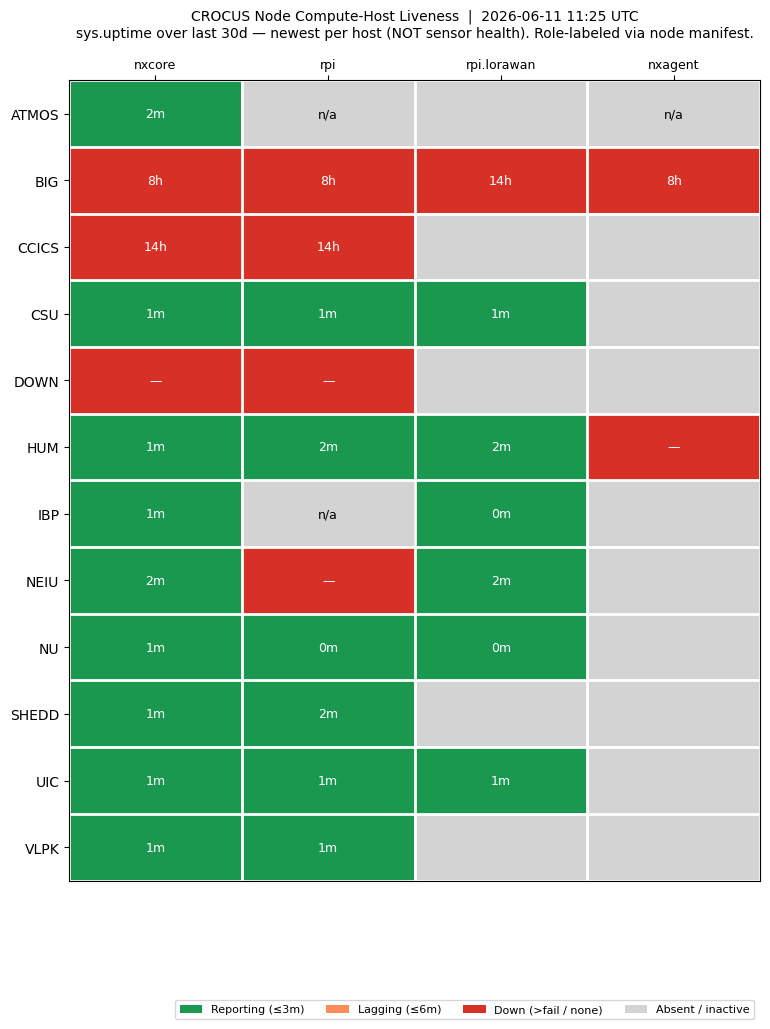

In [3]:
print("Checking node compute-host liveness...")
node_health = check_node_health(ALL_SITES)
plot_node_health(node_health)

## 2. Sensor Status Grid

Current sensor status across all sites. Each cell shows whether the sensor
reported within the lookback window.

- **Green** — reporting
- **Red** — not reporting
- **Gray** — sensor not configured at this site

Continuous sensors (WXT, AQT, BME, sap flow, MFR) use a 6-hour lookback.
The RG-15 rain gauge uses a recency check over a short window: because rain
intensity is legitimately 0 during dry periods, "reporting" means *a reading
arrived recently*, not that the value is non-zero.


Checking sensor status...
  Checking ATMOS (W0A4)... done
  Checking BIG (W0A0)... done
  Checking CCICS (W08B)... done
  Checking CSU (W08E)... done
  Checking DOWN (W09D)... done
  Checking HUM (W0A1)... done
  Checking IBP (W07C)... done
  Checking NEIU (W08D)... done
  Checking NU (W099)... done
  Checking SHEDD (W09E)... done
  Checking UIC (W096)... done
  Checking VLPK (W095)... done


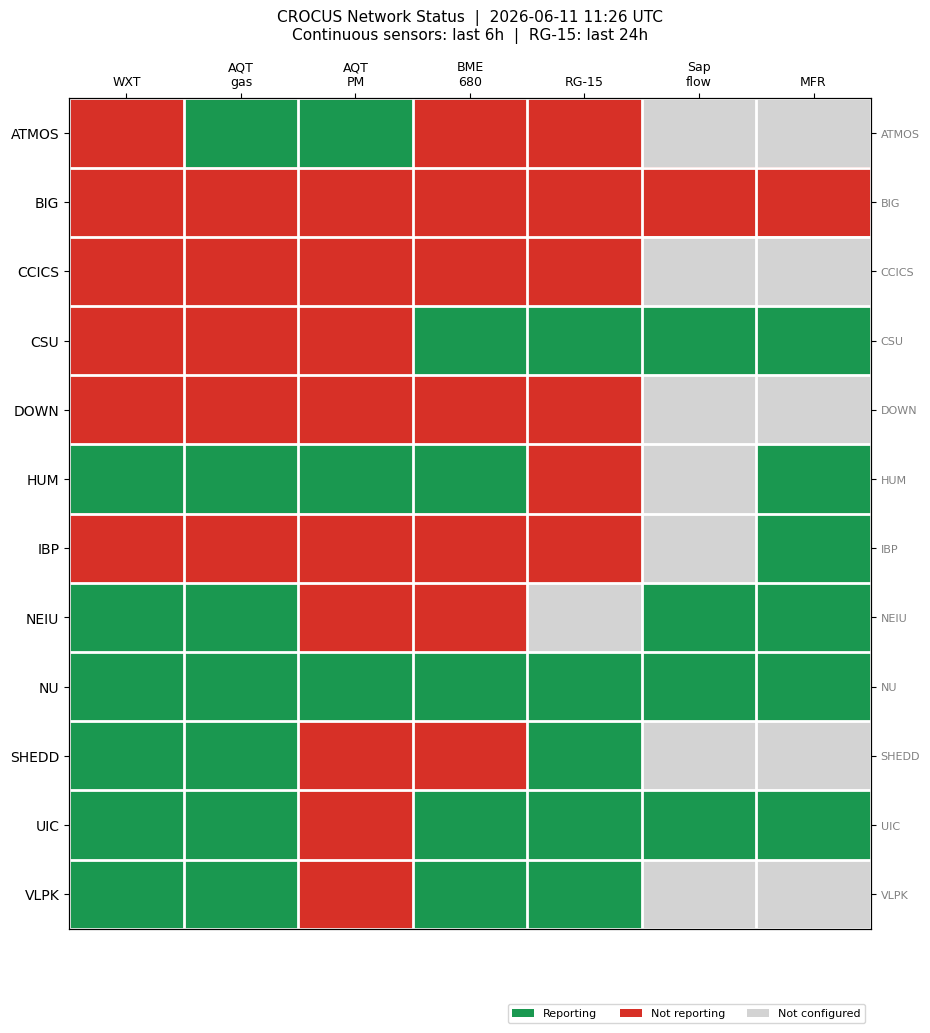

In [4]:
print("Checking sensor status...")
status = check_network_status(ALL_SITES, hours=6, rg15_hours=24)
plot_network_status(status, hours=6, rg15_hours=24)

## 3. Node App History (single node)

Recreates the Sage portal's App History view for one node — time on the x-axis,
one row per plugin, bar height showing record count per time bin. Change `SITE`
to inspect any node.


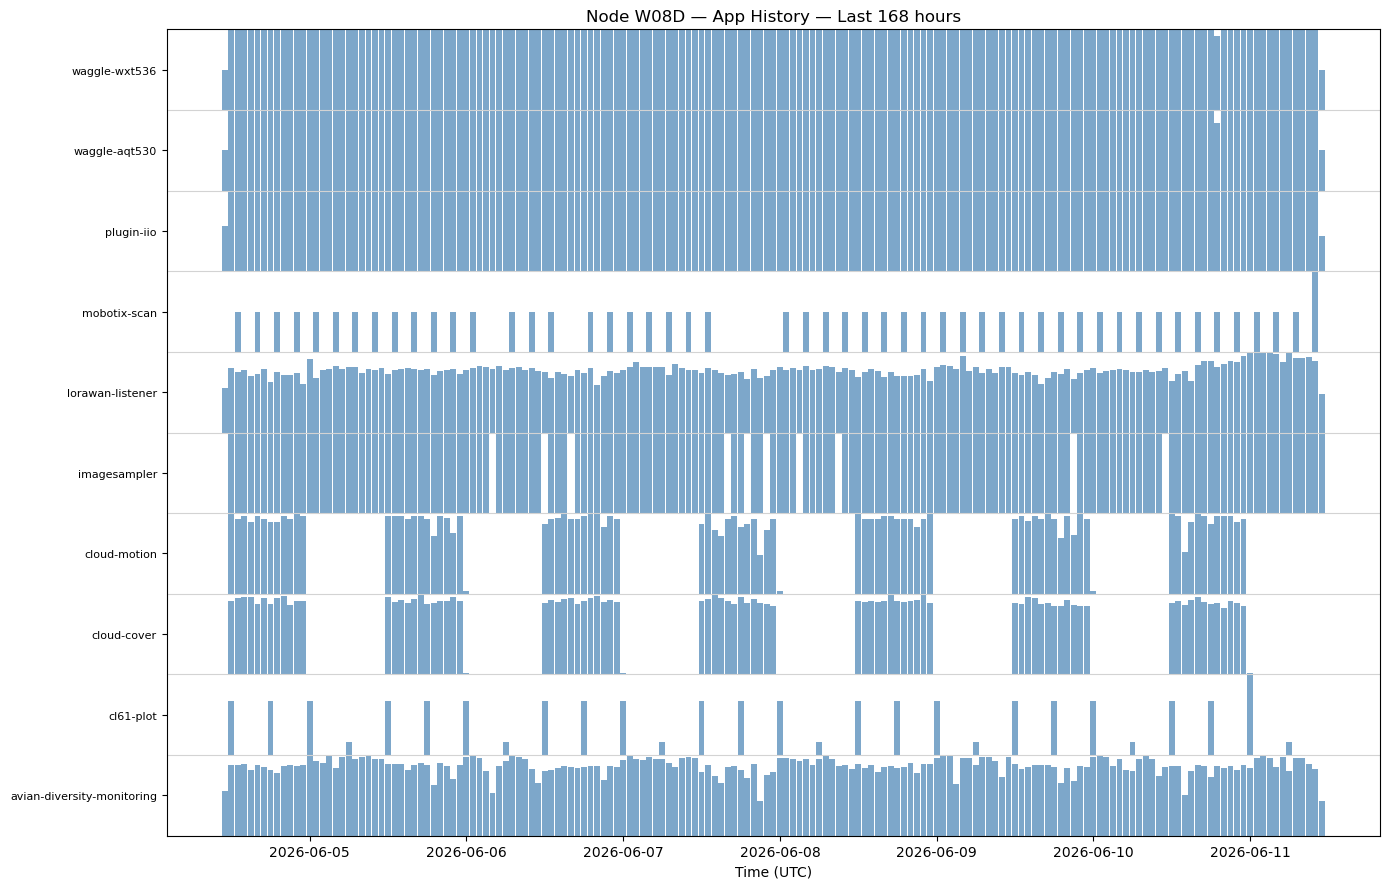

In [5]:
SITE = NEIU
plot_node_status(SITE.vsn, hours=24 * 7)